# AeroNet Lite — Amazon Delivery Demand Forecasting

This notebook trains a demand forecasting model using the **Kaggle Amazon Delivery Dataset**.
If the CSV is not found, the notebook automatically uses synthetic fallback data so the notebook still runs during viva/demo.

In [1]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

## 1. Locate Project Root and Dataset

In [2]:
def find_project_root() -> Path:
    cwd = Path.cwd().resolve()

    # Case 1: notebook is inside project/notebooks
    if cwd.name.lower() == "notebooks":
        return cwd.parent

    # Case 2: notebook is run from project root
    if (cwd / "data").exists() or (cwd / "src").exists():
        return cwd

    # Case 3: fallback to parent search
    for parent in [cwd] + list(cwd.parents):
        if (parent / "data").exists() or (parent / "src").exists():
            return parent

    return cwd


PROJECT_ROOT = find_project_root()
RAW_DIR = PROJECT_ROOT / "data" / "raw"

candidate_files = [
    RAW_DIR / "amazon_delivery.csv",
    RAW_DIR / "amazon_delivery_dataset.csv",
    RAW_DIR / "Amazon Delivery.csv",
    RAW_DIR / "amazon-delivery-dataset" / "amazon_delivery.csv",
]

# Also search all CSV files in data/raw as backup
if RAW_DIR.exists():
    candidate_files.extend(list(RAW_DIR.rglob("*.csv")))

csv_path = next((p for p in candidate_files if p.exists()), None)

print("Project root:", PROJECT_ROOT)
print("Raw data folder:", RAW_DIR)
print("CSV found:", csv_path)

Project root: C:\Users\pixlaps\Desktop\aeronet_lite_interactive
Raw data folder: C:\Users\pixlaps\Desktop\aeronet_lite_interactive\data\raw
CSV found: C:\Users\pixlaps\Desktop\aeronet_lite_interactive\data\raw\amazon_delivery.csv


## 2. Fallback Synthetic Data

This runs only if the Kaggle CSV is missing.

In [3]:
def make_synthetic_delivery_demand(n=700, seed=42):
    rng = np.random.default_rng(seed)

    hour = rng.integers(0, 24, n)
    weekday = rng.integers(0, 7, n)
    weather_code = rng.choice([0, 1, 2, 3], n, p=[0.55, 0.25, 0.15, 0.05])
    traffic_code = rng.choice([0, 1, 2], n, p=[0.35, 0.45, 0.20])
    vehicle_code = rng.choice([0, 1, 2], n, p=[0.45, 0.40, 0.15])
    distance_km = rng.gamma(shape=2.2, scale=3.0, size=n).clip(0.5, 25)
    agent_rating = rng.normal(4.4, 0.35, n).clip(1, 5)

    rush_hour = ((hour >= 8) & (hour <= 10)) | ((hour >= 17) & (hour <= 21))
    weekend = weekday >= 5

    demand = (
        18
        + rush_hour.astype(int) * 24
        + weekend.astype(int) * 9
        + traffic_code * 7
        + weather_code * -3
        + vehicle_code * 3
        + np.maximum(12 - distance_km, 0) * 0.9
        + agent_rating * 4
        + rng.normal(0, 7, n)
    ).clip(2, None)

    return pd.DataFrame({
        "hour": hour,
        "weekday": weekday,
        "weather_code": weather_code,
        "traffic_code": traffic_code,
        "vehicle_code": vehicle_code,
        "distance_km": np.round(distance_km, 2),
        "agent_rating": np.round(agent_rating, 2),
        "demand": np.round(demand, 2),
    })

## 3. Load and Prepare Amazon Delivery Dataset

The Amazon dataset may have slightly different column names depending on version/download.  
This function normalizes common names and creates a grouped `demand` target.

In [4]:
def clean_column_name(col):
    return (
        str(col)
        .strip()
        .lower()
        .replace(" ", "_")
        .replace("-", "_")
        .replace("/", "_")
        .replace("(", "")
        .replace(")", "")
    )


def safe_label_encode(series):
    codes, uniques = pd.factorize(series.astype(str).fillna("Unknown"))
    return codes


def prepare_amazon_delivery_data(path):
    raw = pd.read_csv(path)
    df = raw.copy()
    df.columns = [clean_column_name(c) for c in df.columns]

    print("Original shape:", raw.shape)
    print("Normalized columns:")
    print(df.columns.tolist())

    # Time feature detection
    time_candidates = [
        "order_time", "order_time_", "time_orderd", "time_ordered",
        "order_date", "date", "order_datetime", "datetime"
    ]
    date_col = next((c for c in time_candidates if c in df.columns), None)

    if date_col is not None:
        dt = pd.to_datetime(df[date_col], errors="coerce")
        df["hour"] = dt.dt.hour.fillna(12).astype(int)
        df["weekday"] = dt.dt.weekday.fillna(0).astype(int)
        df["month"] = dt.dt.month.fillna(1).astype(int)
    else:
        # If no datetime column exists, create stable demo features
        rng = np.random.default_rng(42)
        df["hour"] = rng.integers(0, 24, len(df))
        df["weekday"] = rng.integers(0, 7, len(df))
        df["month"] = rng.integers(1, 13, len(df))

    # Distance feature
    distance_candidates = [
        "distance", "distance_km", "delivery_distance", "delivery_distance_km",
        "restaurant_to_customer_distance"
    ]
    dist_col = next((c for c in distance_candidates if c in df.columns), None)
    if dist_col is not None:
        df["distance_km"] = pd.to_numeric(df[dist_col], errors="coerce")
    else:
        rng = np.random.default_rng(43)
        df["distance_km"] = rng.gamma(2.2, 3.0, len(df)).clip(0.5, 25)

    # Agent rating feature
    rating_candidates = ["agent_rating", "delivery_person_ratings", "delivery_person_rating", "ratings"]
    rating_col = next((c for c in rating_candidates if c in df.columns), None)
    if rating_col is not None:
        df["agent_rating"] = pd.to_numeric(df[rating_col], errors="coerce")
    else:
        df["agent_rating"] = 4.2

    # Categorical feature candidates
    weather_candidates = ["weather", "weatherconditions", "weather_condition", "weather_conditions"]
    traffic_candidates = ["traffic", "road_traffic_density", "traffic_density"]
    vehicle_candidates = ["vehicle", "vehicle_type", "type_of_vehicle"]

    weather_col = next((c for c in weather_candidates if c in df.columns), None)
    traffic_col = next((c for c in traffic_candidates if c in df.columns), None)
    vehicle_col = next((c for c in vehicle_candidates if c in df.columns), None)

    df["weather_code"] = safe_label_encode(df[weather_col]) if weather_col else 0
    df["traffic_code"] = safe_label_encode(df[traffic_col]) if traffic_col else 0
    df["vehicle_code"] = safe_label_encode(df[vehicle_col]) if vehicle_col else 0

    # Demand target:
    # For a delivery dataset, demand is represented as order count grouped by time and context.
    group_cols = ["hour", "weekday", "month", "weather_code", "traffic_code", "vehicle_code"]
    demand_df = (
        df.groupby(group_cols, as_index=False)
        .agg(
            demand=("hour", "size"),
            distance_km=("distance_km", "mean"),
            agent_rating=("agent_rating", "mean"),
        )
    )

    # Fixed zone density logic: rank first to avoid qcut duplicate-bin errors.
    if len(demand_df) >= 3 and demand_df["demand"].nunique() >= 3:
        ranked_demand = demand_df["demand"].rank(method="first")
        demand_df["zone_density_level"] = (
            pd.qcut(ranked_demand, q=3, labels=False, duplicates="drop").astype(int) + 1
        )
    else:
        demand_df["zone_density_level"] = 2

    demand_df = demand_df.dropna().reset_index(drop=True)
    return demand_df


if csv_path is not None:
    demand_df = prepare_amazon_delivery_data(csv_path)
    dataset_source = f"Kaggle Amazon Delivery Dataset: {csv_path.name}"
else:
    demand_df = make_synthetic_delivery_demand()
    dataset_source = "Synthetic fallback data because Kaggle CSV was not found"

print("Dataset source:", dataset_source)
print("Prepared shape:", demand_df.shape)
demand_df.head()

Original shape: (43739, 16)
Normalized columns:
['order_id', 'agent_age', 'agent_rating', 'store_latitude', 'store_longitude', 'drop_latitude', 'drop_longitude', 'order_date', 'order_time', 'pickup_time', 'weather', 'traffic', 'vehicle', 'area', 'delivery_time', 'category']
Dataset source: Kaggle Amazon Delivery Dataset: amazon_delivery.csv
Prepared shape: (379, 10)


C:\Users\pixlaps\AppData\Local\Temp\ipykernel_8276\4199145806.py:36: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  dt = pd.to_datetime(df[date_col], errors="coerce")


,hour,weekday,month,weather_code,traffic_code,vehicle_code,demand,distance_km,agent_rating,zone_density_level
0,0,6,5,0,2,0,29,6.745511,4.565517,1
1,0,6,5,0,2,1,32,6.891123,4.553125,1
2,0,6,5,0,2,2,9,6.804151,4.577778,1
3,0,6,5,1,2,0,38,6.143239,4.665789,2
4,0,6,5,1,2,1,33,6.377679,4.748485,2


## 4. Train Demand Forecasting Models

In [5]:
feature_names = [
    "hour",
    "weekday",
    "month" if "month" in demand_df.columns else None,
    "weather_code",
    "traffic_code",
    "vehicle_code",
    "distance_km",
    "agent_rating",
    "zone_density_level" if "zone_density_level" in demand_df.columns else None,
]
feature_names = [f for f in feature_names if f is not None and f in demand_df.columns]

X = demand_df[feature_names]
y = demand_df["demand"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(
        n_estimators=150,
        max_depth=10,
        random_state=42
    ),
}

results = []
trained_models = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, pred)
    rmse = mean_squared_error(y_test, pred) ** 0.5
    r2 = r2_score(y_test, pred)

    results.append({
        "model": name,
        "MAE": round(mae, 3),
        "RMSE": round(rmse, 3),
        "R2": round(r2, 3),
    })
    trained_models[name] = model

results_df = pd.DataFrame(results).sort_values("RMSE")
results_df

,model,MAE,RMSE,R2
1,Random Forest,10.619,17.399,0.982
0,Linear Regression,59.621,73.477,0.680


## 5. Prediction Table

In [6]:
best_model_name = results_df.iloc[0]["model"]
best_model = trained_models[best_model_name]

predictions = best_model.predict(X_test)

preview = X_test.copy()
preview["actual_demand"] = y_test.values
preview["predicted_demand"] = np.round(predictions, 2)

print("Best model:", best_model_name)
preview.head(12)

Best model: Random Forest


,hour,weekday,month,weather_code,traffic_code,vehicle_code,distance_km,agent_rating,zone_density_level,actual_demand,predicted_demand
288,19,6,5,5,3,2,3.214030,4.650000,1,4,7.80
283,19,6,5,5,1,0,6.703323,4.587657,3,398,425.52
327,22,6,5,0,1,2,9.429099,4.750000,1,4,7.07
145,13,6,5,5,0,1,5.531583,4.711111,2,45,50.69
55,10,6,5,0,2,1,7.557042,4.845455,3,110,109.19
93,11,6,5,3,2,1,7.240714,4.733333,1,12,14.02
341,22,6,5,2,2,1,6.151534,4.752263,3,243,240.36
82,11,6,5,1,2,2,18.270528,4.800000,1,1,8.75
366,23,6,5,1,2,2,7.287677,4.738806,2,67,56.67
148,14,6,5,0,0,1,6.233847,4.709091,2,44,52.26


## 6. Actual vs Predicted Plot

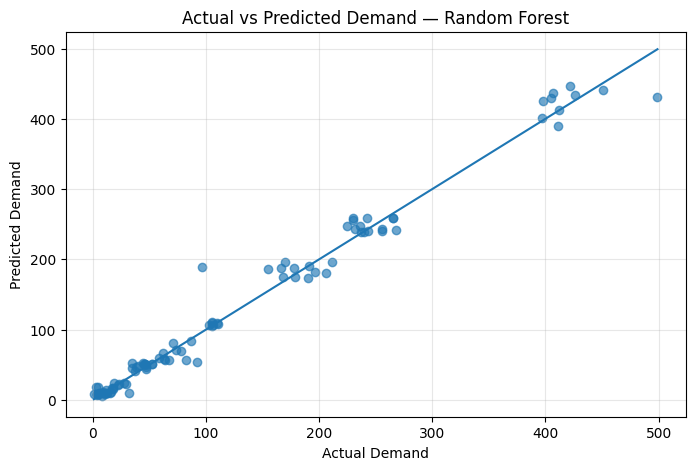

In [7]:
plt.figure(figsize=(8, 5))
plt.scatter(y_test, predictions, alpha=0.65)
plt.xlabel("Actual Demand")
plt.ylabel("Predicted Demand")
plt.title(f"Actual vs Predicted Demand — {best_model_name}")

min_val = min(float(y_test.min()), float(predictions.min()))
max_val = max(float(y_test.max()), float(predictions.max()))
plt.plot([min_val, max_val], [min_val, max_val])
plt.grid(True, alpha=0.3)
plt.show()

## 7. Feature Importance

Random Forest gives feature importance. Linear Regression coefficients are used only if Linear Regression is selected.

In [8]:
if hasattr(best_model, "feature_importances_"):
    importance_df = pd.DataFrame({
        "feature": feature_names,
        "importance": best_model.feature_importances_,
    }).sort_values("importance", ascending=False)
else:
    importance_df = pd.DataFrame({
        "feature": feature_names,
        "coefficient": best_model.coef_,
    }).sort_values("coefficient", ascending=False)

importance_df

,feature,importance
8,zone_density_level,0.763343
0,hour,0.126165
5,vehicle_code,0.102044
7,agent_rating,0.003750
6,distance_km,0.002936
3,weather_code,0.001094
4,traffic_code,0.000665
1,weekday,0.000002
2,month,0.000001


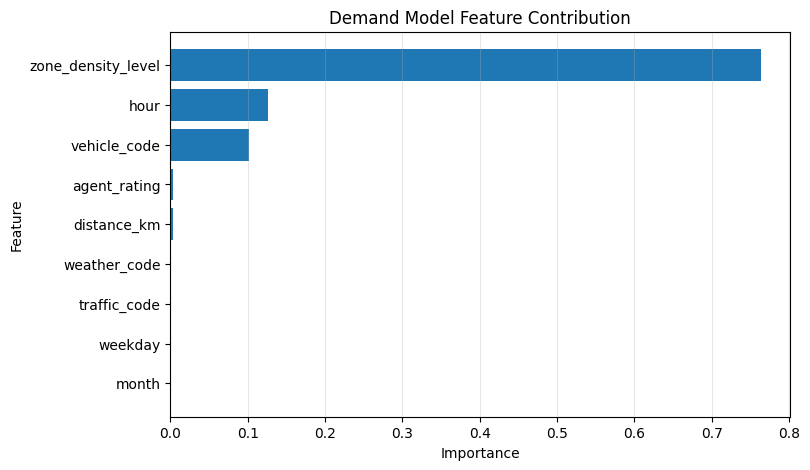

In [9]:
value_col = "importance" if "importance" in importance_df.columns else "coefficient"

plt.figure(figsize=(8, 5))
plt.barh(importance_df["feature"], importance_df[value_col])
plt.xlabel(value_col.title())
plt.ylabel("Feature")
plt.title("Demand Model Feature Contribution")
plt.gca().invert_yaxis()
plt.grid(True, axis="x", alpha=0.3)
plt.show()

## 8. Viva Explanation

- The Amazon Delivery dataset is used because it is closer to real delivery operations than Bike Sharing Demand.
- Individual delivery records are grouped by hour, weekday, weather, traffic, and vehicle type.
- The grouped order count becomes the `demand` target.
- Regression predicts future demand so the fleet selector can estimate how many drones are required.
- If the CSV is missing, fallback data is used only for demonstration and code testing.